In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Level 1:
### Task 1:
---
 Top Cuisines
 Determine the top three most common cuisines in the dataset.

In [6]:
top_cuisines = df['Cuisines'].str.split(', ').explode().value_counts().head(3)

print(top_cuisines)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


Calculate the percentage of restaurants that serve each of the top cuisines.

In [7]:
percentage = (top_cuisines / len(df))*100

print(percentage)

Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


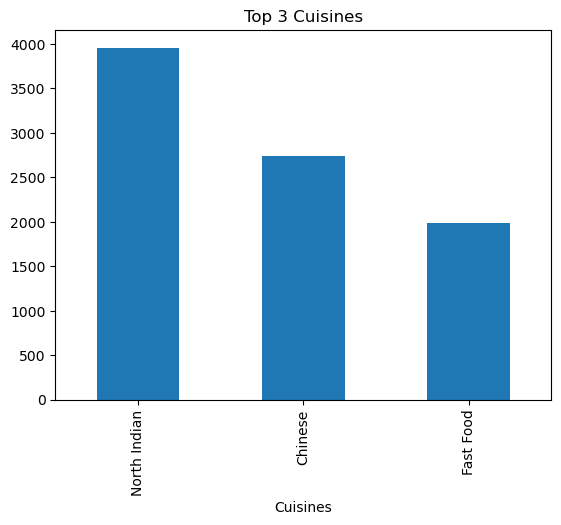

In [8]:
top_cuisines.plot(kind='bar')
plt.title("Top 3 Cuisines")
plt.show()

## Task 2: City Analysis
---
Identify the city with the highest number of restaurants in the dataset.

In [9]:
city_counts = df['City'].value_counts()

print(city_counts.head(1))

City
New Delhi    5473
Name: count, dtype: int64


Calculate the average rating for restaurants in each city.

In [26]:
avg_rating = df.groupby('City')['Aggregate rating'].mean()
print(avg_rating.sort_values(ascending=False).head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


Determine the city with the highest average rating.

In [11]:
print(avg_rating.sort_values(ascending=False).head(1))

City
Inner City    4.9
Name: Aggregate rating, dtype: float64


## Task 3: Price Range Distribution
---
Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.

In [12]:
price_counts = df['Price range'].value_counts().sort_index()

print(price_counts)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


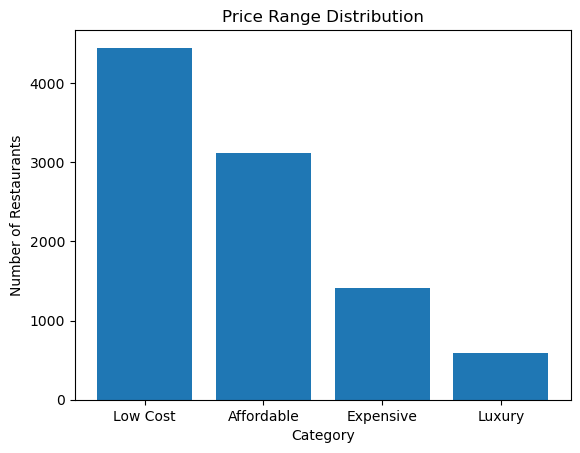

In [15]:
labels = ['Low Cost', 'Affordable', 'Expensive', 'Luxury']

plt.bar(labels, price_counts)

plt.title("Price Range Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Restaurants")

plt.show()
print("Price range values represent increasing cost levels from low to luxury.")

Calculate the percentage of restaurants in each price range category.


In [13]:
price_percentage = (price_counts / len(df)) * 100

print(price_percentage)

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


## Task 4: Online Delivery
---
Determine the percentage of restaurants that offer online delivery.

In [22]:
delivery_yes_counts = (df['Has Online delivery'] == 'Yes').sum()

delivery_percentage = (delivery_yes_counts / len(df)) * 100

print("Percentage of restaurants that offer online delivery:-",delivery_percentage.round(2))

Percentage of restaurants that offer online delivery:- 25.66


Compare the average ratings of restaurants with and without online delivery.

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


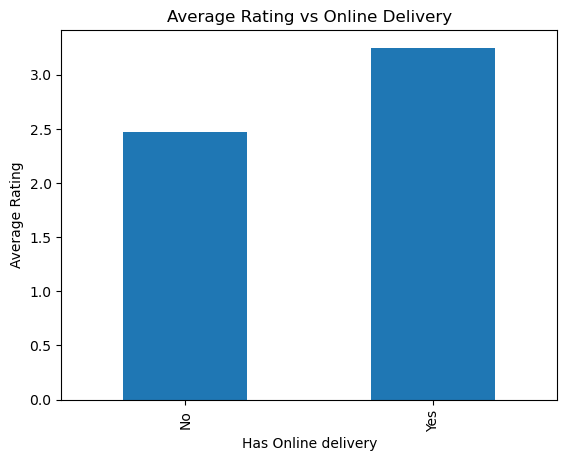

In [25]:
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(avg_rating_delivery)
avg_rating_delivery.plot(kind='bar')

plt.title("Average Rating vs Online Delivery")
plt.ylabel("Average Rating")

plt.show()

Restaurants offering online delivery have slightly higher/lower ratings, indicating the impact of convenience on customer satisfaction.